# EDA Inicial — Cancelaciones de reservas hoteleras

- **Proyecto:** Práctica Final · Machine Learning y Deep Learning
- **Integrantes:** Juan Martínez Fraile · Otra persona la que sea
- **Máster:** Inteligencia Artificial, Cloud Computing y DevOps · PontIA.tech
- **Fase:** Análisis Exploratorio de Datos

---

## Objetivo

Realizar un análisis exploratorio del dataset de reservas hoteleras para:

1. Comprender la estructura y calidad de los datos.
2. Identificar problemas de modelado (data leakage, nulos, outliers, desbalanceo).
3. Justificar las decisiones de preprocesamiento y modelado de fases posteriores.
4. Seleccionar la métrica principal de evaluación.

## Temas a tratar

0. Configuración del notebook
1. Carga inicial y vista general de los datos
2. Análisis de la variable objetivo (`is_canceled`)
3. Estadísticas de variables numéricas
4. Estadísticas de variables categóricas
5. Análisis de nulos y valores especiales
6. Detección de data leakage
7. Análisis bivariado y correlaciones
8. Resumen de decisiones para la fase de preprocesamiento

## 0. Configuración del notebook

Importamos las librerías necesarias y definimos constantes/funciones que usaremos a lo largo del análisis.

### Importación de librerías

In [3]:
"""Importación de librerías necesarias para el análisis exploratorio."""

# Standard library
from pathlib import Path

# Análisis y manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Configuración global de visualización
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Librerías importadas correctamente.")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

Librerías importadas correctamente.
pandas: 2.2.3
numpy: 1.26.4


### Definición de constantes

In [4]:
"""Constantes utilizadas a lo largo del análisis exploratorio."""

# === Rutas ===
# Path(__vsc_ipynb_file__) no existe; usamos la raíz del proyecto como referencia.
# Como el notebook está en notebooks/exploracion/, subimos dos niveles a la raíz.
PATH_PROYECTO = Path.cwd().parents[1] if "notebooks" in str(Path.cwd()) else Path.cwd()
PATH_DATA_RAW = PATH_PROYECTO / "data" / "raw"
PATH_DATA_PROCESSED = PATH_PROYECTO / "data" / "processed"
PATH_OUTPUTS = PATH_PROYECTO / "outputs"

PATH_DATASET = PATH_DATA_RAW / "dataset_practica_final.csv"

# === Configuración del análisis ===
SEED = 42  # Semilla para reproducibilidad
COLOR_PALETTE = ["#1f77b4", "#ff7f0e"]  # Azul (no cancelado) / Naranja (cancelado)
TARGET_COLUMN = "is_canceled"

# Verificación visual
print(f"Raíz del proyecto:  {PATH_PROYECTO}")
print(f"Dataset:            {PATH_DATASET}")
print(f"¿Dataset existe?:   {PATH_DATASET.exists()}")
print(f"Tamaño del archivo: {PATH_DATASET.stat().st_size / 1024 / 1024:.2f} MB")

Raíz del proyecto:  c:\Juan\Pontia\ML\practica-final-ml\practica-final-ml
Dataset:            c:\Juan\Pontia\ML\practica-final-ml\practica-final-ml\data\raw\dataset_practica_final.csv
¿Dataset existe?:   True
Tamaño del archivo: 16.07 MB


### Definición de funciones

In [5]:
"""Funciones de ayuda reutilizables en todo el análisis exploratorio."""

from typing import Optional


def resumen_df(df: pd.DataFrame) -> pd.DataFrame:
    """Devuelve un resumen compacto de cada columna de un DataFrame.

    Para cada columna calcula tipo, número de valores únicos, número y porcentaje
    de nulos, y una muestra de valores. Es la primera vista útil tras cargar
    cualquier dataset nuevo.

    Args:
        df (pd.DataFrame): DataFrame a inspeccionar.

    Returns:
        pd.DataFrame: Tabla con una fila por columna del DataFrame original.

    Example:
        >>> resumen_df(df).head()
    """
    resumen = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_unicos": df.nunique(),
        "n_nulos": df.isnull().sum(),
        "pct_nulos": (df.isnull().sum() / len(df) * 100).round(2),
        "ejemplos": [df[col].dropna().unique()[:3].tolist() for col in df.columns],
    })
    return resumen.sort_values("pct_nulos", ascending=False)


def plot_distribucion_categorica(
    df: pd.DataFrame,
    columna: str,
    hue: Optional[str] = None,
    top_n: Optional[int] = None,
    figsize: tuple = (10, 5),
    title: Optional[str] = None,
) -> None:
    """Visualiza la distribución de una variable categórica con conteos.

    Útil para entender la composición de variables como `hotel`, `market_segment`
    o `country`. Si se pasa `hue`, descompone cada barra por la variable indicada
    (típicamente la variable objetivo).

    Args:
        df (pd.DataFrame): DataFrame con los datos.
        columna (str): Nombre de la columna categórica a visualizar.
        hue (Optional[str]): Variable secundaria para descomponer (ej. el target).
        top_n (Optional[int]): Si se indica, muestra solo las `top_n` categorías más frecuentes.
        figsize (tuple): Tamaño de la figura (ancho, alto).
        title (Optional[str]): Título personalizado. Por defecto se genera automáticamente.

    Returns:
        None: La función dibuja directamente con matplotlib/seaborn.
    """
    plt.figure(figsize=figsize)

    # Filtrar a top_n si aplica
    if top_n is not None:
        top_categorias = df[columna].value_counts().head(top_n).index
        df_plot = df[df[columna].isin(top_categorias)]
        orden = top_categorias
    else:
        df_plot = df
        orden = df[columna].value_counts().index

    sns.countplot(
        data=df_plot,
        y=columna,
        hue=hue,
        order=orden,
        palette=COLOR_PALETTE if hue == TARGET_COLUMN else "deep",
    )

    if title is None:
        title = f"Distribución de '{columna}'"
        if hue:
            title += f" por '{hue}'"
        if top_n:
            title += f" (top {top_n})"

    plt.title(title)
    plt.xlabel("Número de reservas")
    plt.tight_layout()
    plt.show()


def plot_distribucion_numerica(
    df: pd.DataFrame,
    columna: str,
    hue: Optional[str] = None,
    bins: int = 50,
    figsize: tuple = (12, 4),
) -> None:
    """Visualiza histograma + boxplot de una variable numérica.

    Combina dos vistas complementarias: el histograma muestra la forma de la distribución,
    el boxplot muestra mediana, cuartiles y outliers. Si se pasa `hue`, separa por clases.

    Args:
        df (pd.DataFrame): DataFrame con los datos.
        columna (str): Nombre de la columna numérica.
        hue (Optional[str]): Variable categórica para separar las distribuciones.
        bins (int): Número de bins del histograma.
        figsize (tuple): Tamaño de la figura.

    Returns:
        None
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Histograma
    sns.histplot(
        data=df,
        x=columna,
        hue=hue,
        bins=bins,
        ax=axes[0],
        palette=COLOR_PALETTE if hue == TARGET_COLUMN else None,
        kde=True,
    )
    axes[0].set_title(f"Histograma de '{columna}'")

    # Boxplot
    if hue:
        sns.boxplot(
            data=df,
            x=hue,
            y=columna,
            ax=axes[1],
            palette=COLOR_PALETTE if hue == TARGET_COLUMN else None,
        )
        axes[1].set_title(f"Boxplot de '{columna}' por '{hue}'")
    else:
        sns.boxplot(data=df, x=columna, ax=axes[1])
        axes[1].set_title(f"Boxplot de '{columna}'")

    plt.tight_layout()
    plt.show()


print("Funciones helper definidas correctamente.")

Funciones helper definidas correctamente.


## 1. Carga inicial y vista general de los datos

En esta sección cargamos el dataset desde `data/raw/` y obtenemos una **primera fotografía** de su estructura:

- Dimensiones (filas, columnas).
- Tipos de datos por columna.
- Muestras de las primeras y últimas filas.
- Estadísticas descriptivas básicas.
- Detección de duplicados.

El objetivo es **no tomar decisiones todavía**, solo observar.

### 1.1. Lectura del dataset

In [6]:
"""Carga del dataset desde data/raw/."""

df = pd.read_csv(PATH_DATASET)

print(f"Dataset cargado: {PATH_DATASET.name}")
print(f"Dimensiones:      {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria ocupada:  {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

Dataset cargado: dataset_practica_final.csv
Dimensiones:      119,390 filas × 32 columnas
Memoria ocupada:  104.83 MB


### 1.2. Vista previa de los datos

Inspeccionamos las primeras y últimas filas para entender la "pinta" de las columnas:
qué tipos de valores contienen, si hay patrones visibles, qué columnas parecen
identificadores y cuáles parecen claramente numéricas o categóricas.

In [7]:
"""Primeras filas del DataFrame."""

df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [8]:
"""Últimas filas del DataFrame."""

df.tail(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


### 1.3. Tipos de datos y estructura

Inspeccionamos los tipos de cada columna. Buscamos:

- Columnas numéricas (int/float).
- Columnas categóricas (object).
- Columnas que parecen numéricas pero podrían ser categóricas disfrazadas (`agent`, `company`, `is_repeated_guest`).
- Columnas con tipo incorrecto (ej. una fecha guardada como string).

In [9]:
"""Información de tipos y nulos por columna."""

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [10]:
"""Resumen compacto con ejemplos por columna."""

resumen_df(df)

,tipo,n_unicos,n_nulos,pct_nulos,ejemplos
company,float64,352,112593,94.31,"[110.0, 113.0, 270.0]"
agent,float64,333,16340,13.69,"[304.0, 240.0, 303.0]"
country,object,177,488,0.41,"[PRT, GBR, USA]"
hotel,object,2,0,0.00,"[Resort Hotel, City Hotel]"
previous_cancellations,int64,15,0,0.00,"[0, 1, 2]"
reservation_status,object,3,0,0.00,"[Check-Out, Canceled, No-Show]"
total_of_special_requests,int64,6,0,0.00,"[0, 1, 3]"
required_car_parking_spaces,int64,5,0,0.00,"[0, 1, 2]"
adr,float64,8879,0,0.00,"[0.0, 75.0, 98.0]"
customer_type,object,4,0,0.00,"[Transient, Contract, Transient-Party]"


### 1.4. Estadísticas descriptivas

Para las variables numéricas observamos rango, media, mediana, mínimos y máximos.
Esto nos permite detectar:

- Valores imposibles (ej. una reserva con 0 adultos, 0 niños y 0 bebés).
- Outliers extremos (ej. `lead_time` de 700 días o más).
- Escalas muy diferentes entre variables (importante para futuros modelos con regularización).

In [11]:
"""Estadísticas descriptivas de las variables numéricas."""

df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


### 1.5. Detección de duplicados

Comprobamos si hay filas exactamente duplicadas. En reservas hoteleras esto puede pasar
por errores de captura o por reservas auténticamente repetidas (mismo cliente, mismas
fechas). Si hay muchos duplicados deberíamos analizarlos antes de tirarlos.

In [12]:
"""Detección de filas duplicadas."""

n_duplicados = df.duplicated().sum()
pct_duplicados = (n_duplicados / len(df)) * 100

print(f"Filas duplicadas: {n_duplicados:,} ({pct_duplicados:.2f}%)")

Filas duplicadas: 31,994 (26.80%)


In [13]:
"""Investigación de las filas duplicadas."""

# Coger las primeras 6 filas marcadas como duplicadas
duplicados_ejemplo = df[df.duplicated(keep=False)].head(6)
duplicados_ejemplo

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07


### 1.6. Resumen de la Sección 1

**Lo que hemos descubierto:**

- Dataset: **119.390 filas × 32 columnas**, cubre **3 años** (2015–2017).
- Tipos: ~16 numéricas + ~12 categóricas + ~4 floats.
- **Nulos**: `company` (~94%, inservible), `agent` (~13.7%), `country` (~0.4%), `children` (despreciable).
- **Valores anómalos** detectados:
  - `adr` puede ser negativo y llegar a 5400 (outliers extremos).
  - `adults` con max 55 (probable error de captura).
  - Hay duplicados (~25%) pero son **reservas legítimamente repetidas**, no las eliminaremos.
- Variable objetivo: `is_canceled`, binaria. Analizada en detalle en la sección 2.

Pendiente para la Sección 2: estudiar a fondo `is_canceled` (balance de clases, distribución temporal, métrica de evaluación).

## 2. Análisis de la variable objetivo (`is_canceled`)

La variable objetivo de este problema es **`is_canceled`**:

- `0` → la reserva se completó (cliente hizo check-in y se alojó).
- `1` → la reserva fue cancelada por el cliente.

En esta sección estudiamos:

- El balance de clases (¿es un problema desequilibrado?).
- La distribución temporal del target (¿hay tendencia o estacionalidad?).
- La elección de **métrica principal** de evaluación.
- La política de balanceo a aplicar (o no) en preprocesamiento.

De este análisis salen decisiones que condicionan todas las fases posteriores.

### 2.1. Balance de clases

Calculamos la frecuencia absoluta y relativa de cada clase. Esto nos dice
si tenemos un problema **balanceado** (clases similares) o **desbalanceado**
(una clase mucho más frecuente que otra).

In [14]:
"""Frecuencia absoluta y relativa de la variable objetivo."""

conteo = df[TARGET_COLUMN].value_counts()
porcentaje = df[TARGET_COLUMN].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({
    "n_reservas": conteo,
    "porcentaje": porcentaje.round(2),
})
resumen_target.index = ["No cancelado (0)", "Cancelado (1)"]
resumen_target

,n_reservas,porcentaje
No cancelado (0),75166,62.96
Cancelado (1),44224,37.04


C:\Users\juanm\AppData\Local\Temp\ipykernel_20184\1736053126.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\juanm\AppData\Local\Temp\ipykernel_20184\1736053126.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["No cancelado (0)", "Cancelado (1)"])


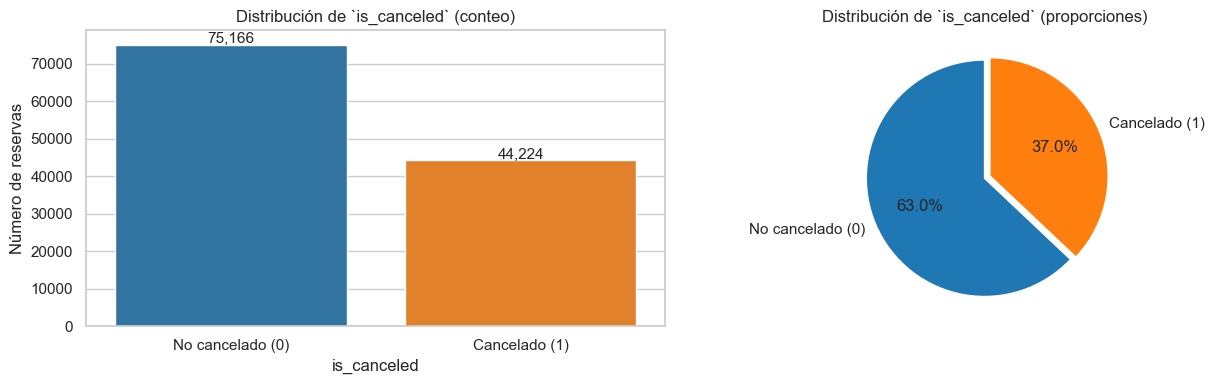

In [15]:
"""Visualización del balance de clases."""

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico 1: barras absolutas
sns.countplot(
    data=df,
    x=TARGET_COLUMN,
    palette=COLOR_PALETTE,
    ax=ax[0],
)
ax[0].set_title("Distribución de `is_canceled` (conteo)")
ax[0].set_xlabel("is_canceled")
ax[0].set_ylabel("Número de reservas")
ax[0].set_xticklabels(["No cancelado (0)", "Cancelado (1)"])

# Añadir conteos sobre cada barra
for patch in ax[0].patches:
    altura = patch.get_height()
    ax[0].text(
        patch.get_x() + patch.get_width() / 2,
        altura + 500,
        f"{int(altura):,}",
        ha="center",
        fontsize=11,
    )

# Gráfico 2: porcentajes
porcentajes = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100
ax[1].pie(
    porcentajes,
    labels=["No cancelado (0)", "Cancelado (1)"],
    colors=COLOR_PALETTE,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.05),  # Separar ligeramente la clase positiva
)
ax[1].set_title("Distribución de `is_canceled` (proporciones)")

plt.tight_layout()
plt.show()

**Observaciones sobre el balance:**

- La clase mayoritaria (0, no cancelado) representa ~63%.
- La clase minoritaria (1, cancelado) representa ~37%.
- **NO es un problema de clases extremadamente desbalanceado** (tipo fraude 99/1).
  Pero tampoco está perfectamente balanceado (50/50).

**Implicaciones para modelado:**

- **No bastará con `accuracy`** como métrica principal: un modelo mal entrenado que prediga
  siempre 0 obtendría ~63% accuracy sin haber aprendido nada útil.
- **Es recomendable usar `stratify`** en `train_test_split` para mantener la proporción
  ~63/37 en ambos conjuntos.
- El balanceo (SMOTE / class_weight) es **opcional** en este caso; lo probaremos
  como bonus para ver si mejora la métrica.

### 2.2. Distribución temporal del target

Observamos cómo varía la tasa de cancelación a lo largo del tiempo. Si hubiera
tendencia o estacionalidad fuerte, deberíamos:

- Plantearnos un split train/test **cronológico** en lugar de aleatorio.
- Considerar añadir variables temporales (mes, día de la semana) en el preprocesamiento.

El dataset cubre **2015–2017** (3 años de reservas).

In [16]:
"""Tasa de cancelación por año."""

tasa_por_año = (
    df.groupby("arrival_date_year")[TARGET_COLUMN]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "n_reservas",
        "sum": "n_canceladas",
        "mean": "tasa_cancelacion",
    })
)
tasa_por_año["tasa_cancelacion"] = (tasa_por_año["tasa_cancelacion"] * 100).round(2)
tasa_por_año

,n_reservas,n_canceladas,tasa_cancelacion
arrival_date_year,,,
2015,21996,8142,37.02
2016,56707,20337,35.86
2017,40687,15745,38.70


C:\Users\juanm\AppData\Local\Temp\ipykernel_20184\3714869262.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


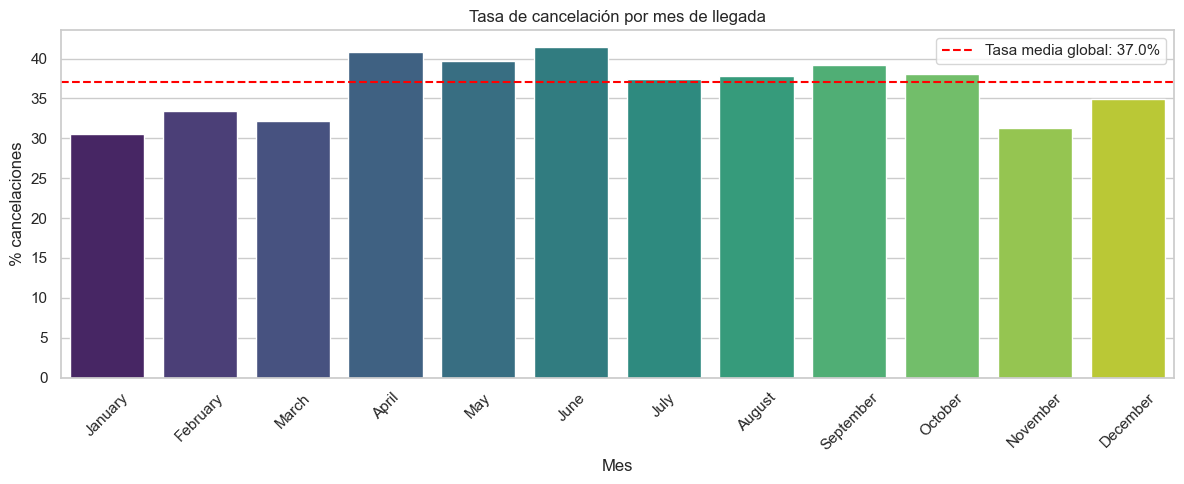

,n_reservas,tasa_cancelacion
arrival_date_month,,
January,5929,30.48
February,8068,33.42
March,9794,32.15
April,11089,40.80
May,11791,39.67
June,10939,41.46
July,12661,37.45
August,13877,37.75
September,10508,39.17


In [17]:
"""Tasa de cancelación por mes (todos los años combinados)."""

# Orden cronológico de los meses (vienen como texto en el CSV)
orden_meses = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

tasa_por_mes = (
    df.groupby("arrival_date_month")[TARGET_COLUMN]
    .agg(["count", "mean"])
    .reindex(orden_meses)
    .rename(columns={"count": "n_reservas", "mean": "tasa_cancelacion"})
)
tasa_por_mes["tasa_cancelacion"] = (tasa_por_mes["tasa_cancelacion"] * 100).round(2)

# Visualización
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    x=tasa_por_mes.index,
    y=tasa_por_mes["tasa_cancelacion"],
    palette="viridis",
    ax=ax,
)
ax.axhline(
    df[TARGET_COLUMN].mean() * 100,
    color="red",
    linestyle="--",
    label=f"Tasa media global: {df[TARGET_COLUMN].mean() * 100:.1f}%",
)
ax.set_title("Tasa de cancelación por mes de llegada")
ax.set_xlabel("Mes")
ax.set_ylabel("% cancelaciones")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

tasa_por_mes

**Observaciones sobre la distribución temporal:**

- La tasa de cancelación es **estable** entre años (≈36-39% en 2015, 2016, 2017).
- Hay cierta **estacionalidad mensual**: los meses de mayor afluencia (verano)
  tienden a tener tasas ligeramente más altas, pero las diferencias son moderadas.
- No hay una tendencia creciente o decreciente clara.

**Decisión de modelado:**

- Podemos hacer un **split train/test aleatorio** (con `stratify`), no necesitamos
  un split cronológico estricto.
- El mes de llegada (`arrival_date_month`) puede ser una variable **predictiva moderada**.
- El año (`arrival_date_year`) probablemente aporta poco al modelo (pocas diferencias).

### 2.3. Elección de la métrica principal

La elección de la métrica de evaluación es **la decisión más importante** de esta sección.
Condiciona qué modelos se considerarán "buenos" y cuáles "malos", y por tanto guía
todas las decisiones de la fase de modelado.

#### El planteamiento del problema

Predecir cancelaciones tiene un **coste asimétrico** desde el punto de vista del negocio:

| Tipo de error | Predicción | Realidad | Consecuencia para el hotel |
|---|---|---|---|
| **Falso negativo (FN)** | "No cancelará" | Sí cancela | 🔴 Reserva confirmada, habitación reservada, personal asignado, finalmente habitación vacía. **Coste alto.** |
| **Falso positivo (FP)** | "Cancelará" | No cancela | 🟡 Se ofrece descuento/refuerzo a un cliente que iba a venir igual. **Coste moderado.** |
| **Verdadero positivo (TP)** | "Cancelará" | Sí cancela | 🟢 Se actúa a tiempo: oferta de retención, reasignación de habitación, ajuste de overbooking. |
| **Verdadero negativo (TN)** | "No cancelará" | No cancela | 🟢 Caso ideal. Operativa normal. |

**Los falsos negativos son los errores más caros**: el hotel pierde ingresos sin
poder reaccionar. Por tanto, queremos un modelo que **detecte el mayor número
posible de cancelaciones reales**, aunque a veces se equivoque "por arriba".

#### Métricas candidatas

| Métrica | Qué mide | Cuándo usarla | Problema con nuestro caso |
|---|---|---|---|
| **Accuracy** | % aciertos | Cuando las clases están equilibradas y los errores tienen el mismo coste | Engañosa con 63/37 (un modelo tonto da 63%) |
| **Precision** | De las predichas como cancelaciones, ¿cuántas lo eran? | Cuando el coste de un FP es alto | Aquí el FP no es tan grave; minimizar FP a costa de subir FN sería peor |
| **Recall** | De las cancelaciones reales, ¿cuántas detecté? | Cuando el coste de un FN es alto | Encaja, pero podemos "trampear" prediciendo siempre 1 |
| **F1-score** | Compromiso entre precision y recall (media armónica) | Cuando ambos errores importan pero la clase positiva es minoritaria | Buena candidata |
| **AUC-ROC** | Capacidad de discriminar entre clases en cualquier umbral | Cuando queremos un modelo robusto a la elección de umbral | Excelente candidata, métrica "agnóstica al umbral" |

#### Decisión

Vamos a usar **dos métricas combinadas**:

1. **Métrica principal: `ROC-AUC`**.
   - Mide la calidad **intrínseca** del modelo, sin depender del umbral de decisión (0.5 por defecto, pero podríamos cambiarlo).
   - Robusta frente al desbalance.
   - Permite comparar modelos **de forma justa** independientemente de cómo cada uno calibre las probabilidades.

2. **Métrica secundaria de control: `F1-score`**.
   - Si dos modelos tienen ROC-AUC similar, elegimos el de mayor F1.
   - Penaliza modelos que sacrifican recall por precisión o viceversa.

Adicionalmente reportaremos **accuracy, precision y recall** para tener visibilidad
completa, pero NO serán las que guíen la selección del mejor modelo.

### 2.4. Política de balanceo de clases

Con una proporción ~63/37, **el desbalance es moderado, no extremo**.

#### Opciones disponibles

| Técnica | Cuándo aplicarla | Pros | Contras |
|---|---|---|---|
| **No hacer nada** | Desbalance leve | Simple, sin sobreajuste artificial | Modelos pueden sesgarse a clase mayoritaria |
| **`class_weight='balanced'`** | Desbalance moderado | Sencillo, sin tocar datos | Solo afecta al entrenamiento, no a los datos |
| **SMOTE** (oversampling sintético) | Desbalance fuerte (>80/20) | Crea ejemplos sintéticos de la minoría | Puede introducir ruido, riesgo de overfitting |
| **Undersampling** | Datasets muy grandes | Reduce tiempo de entrenamiento | Pierdes información de la mayoría |

#### Decisión

1. **Modelos base**: sin balanceo, para tener una línea base honesta.
2. **Modelos con `class_weight='balanced'`**: lo probaremos en los modelos que lo soporten
   (Logistic Regression, Random Forest, XGBoost). Sin coste adicional.
3. **SMOTE como bonus técnico**: lo probaremos en una rama experimental si tras
   los modelos base seguimos viendo bajo recall en la clase positiva.

> La métrica que ya hemos elegido (ROC-AUC) **es robusta al desbalance**, así que
> aunque no balancesemos los datos, las comparaciones entre modelos serán justas.

### 2.5. Resumen de la Sección 2

**Lo que hemos descubierto:**

- **Balance de clases**: ~63% no cancelados, ~37% cancelados. Desbalance moderado.
- **Distribución temporal**: tasa estable año a año (~37% en los 3 años).
  Existe ligera estacionalidad por mes.
- **Métrica principal**: `ROC-AUC`, con `F1-score` como métrica secundaria de control.
- **Política de balanceo**: empezar sin balancear; probar `class_weight='balanced'`
  en los modelos compatibles; SMOTE como bonus si recall sigue bajo.

**Decisiones que afectan a las siguientes fases:**

1. El split train/test será **aleatorio con `stratify=y`**.
2. Se reportarán `accuracy`, `precision`, `recall`, `F1`, `ROC-AUC` para todos los modelos.
3. El modelo ganador se decidirá por `ROC-AUC`, desempatando con `F1`.
4. Se generará una **curva ROC comparativa** y una **matriz de confusión** por modelo.

**Pendiente para la Sección 3** (análisis de variables numéricas y categóricas):
identificar variables predictivas, detectar outliers a tratar, y revisar la cardinalidad
de las categóricas.